<a href="https://colab.research.google.com/github/realclovisworld/Neural_Networks/blob/main/Task_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 5

**(QN)** Design and implement a CNN model (with 2+ layers of convolutions) to classify multi category image datasets. Use the concept of padding and batch normalization while designing the CNN model. Record the accuracy corresponding to the number of epochs.


# STEPS



1. Import packages  
2. Load the MNIST dataset
3. Data normalisation/ Preprocessing
4. Define CNN architecture
5. Define loss, optimizer,
6. Train the model
7. Evaluate



In [ ]:
#Import python packages

import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten,Conv2D, MaxPooling2D,BatchNormalization
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Load tthe MNIST dataset

(train_X,train_Y),(test_X,test_Y) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print('Shape of train_X:', train_X.shape)
print('Shape of test_X:', test_X.shape)
print('Shape of train_Y:', train_Y.shape)
print('Shape of test_Y:', test_Y.shape)


Shape of train_X: (60000, 28, 28)
Shape of test_X: (10000, 28, 28)
Shape of train_Y: (60000,)
Shape of test_Y: (10000,)


In [ ]:
#preprocessing and normalisation
train_X = train_X.reshape(-1,28,28,1)
test_X = test_X.reshape(-1,28,28,1)

train_X = train_X.astype('float32')/255
test_X = test_X.astype('float32')/255

train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)


In [ ]:
print('Shape of train_X after reshaping:', train_X.shape)
print('Shape of test_X after reshaping:', test_X.shape)


Shape of train_X after reshaping: (60000, 28, 28, 1)
Shape of test_X after reshaping: (10000, 28, 28, 1)


In [ ]:
#define architecture
model = Sequential()

model.add(Conv2D(256, (3,3), input_shape=(28,28,1), padding='same'))
model.add(Activation('relu'))
BatchNormalization()
model.add(MaxPooling2D(pool_size=(2,2),padding='same'))

model.add(Conv2D(128, (3,3), padding='same'))
model.add(Activation('relu'))
BatchNormalization()
model.add(MaxPooling2D(pool_size=(2,2),padding='same'))

model.add(Flatten())
model.add(Dense(64))
model.add(Dense(10))
model.add(Activation('softmax'))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 256)    │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 699,722 (2.67 MB)

 Trainable params: 699,722 (2.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#compile model
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

In [ ]:
#train model
model.fit(train_X,train_Y_one_hot,batch_size=64,epochs=8)

Epoch 1/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.8594 - loss: 0.3909
Epoch 2/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9069 - loss: 0.2617
Epoch 3/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9194 - loss: 0.2218
Epoch 4/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9289 - loss: 0.1938
Epoch 5/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9383 - loss: 0.1695
Epoch 6/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9444 - loss: 0.1521
Epoch 7/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9500 - loss: 0.1353
Epoch 8/8
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9577 - loss: 0.1159


In [ ]:
#Evaluate the model

test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9156 - loss: 0.2949
Test loss: 0.29488471150398254
Test accuracy: 0.9156000018119812


In [ ]:
#Make predictions
predictions = model.predict(test_X)
print(np.argmax(np.round(predictions[0])))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
9


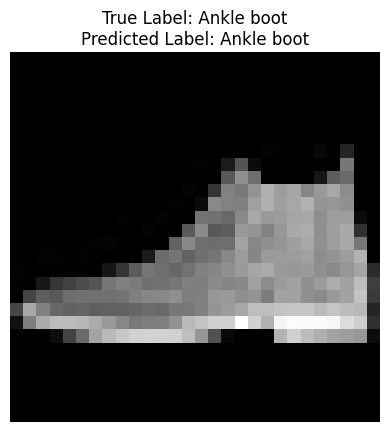

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Choose an index to visualize (e.g., the first test image)
img_index = 0

# Get the original image (reshaped back for display)
image_to_show = test_X[img_index].reshape(28, 28)

# Get the true label
true_label = class_names[test_Y[img_index]]

# Get the predicted label from the `predictions` array
predicted_label = class_names[np.argmax(predictions[img_index])]

# Display the image and its labels
plt.imshow(image_to_show, cmap='gray')
plt.title(f"True Label: {true_label}\nPredicted Label: {predicted_label}")
plt.axis('off')
plt.show()